###Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, GridSearchCV, validation_curve, learning_curve)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier


Aqui fijamos una semilla para reproducir los resultados

In [2]:
np.random.seed(3435)

###cargue de datos

In [11]:
creditotrain = pd.read_excel("creditotrain.xlsx")
creditotest  = pd.read_excel("creditotest.xlsx")



In [12]:
print("Dimensiones train:", creditotrain.shape)
print("Columnas train:", creditotrain.columns.tolist())
print(creditotrain.info())


Dimensiones train: (439, 5)
Columnas train: ['tiempo', 'vendedor', 'tipo_cliente', 'condicion', 'resultado']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tiempo        439 non-null    object
 1   vendedor      439 non-null    object
 2   tipo_cliente  439 non-null    object
 3   condicion     439 non-null    object
 4   resultado     439 non-null    object
dtypes: object(5)
memory usage: 17.3+ KB
None


In [13]:
print(creditotest.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tiempo        441 non-null    object
 1   vendedor      441 non-null    object
 2   tipo_cliente  441 non-null    object
 3   condicion     441 non-null    object
 4   resultado     441 non-null    object
dtypes: object(5)
memory usage: 17.4+ KB
None


Aqui volvemos las columnas categóricas.

In [14]:
cat_cols = creditotrain.columns[:5].tolist()  # primeras 5 columnas como categóricas
for c in cat_cols:
    creditotrain[c] = creditotrain[c].astype("category")
    # Intentamos forzar categorías consistentes también en test
    creditotest[c] = pd.Categorical(creditotest[c], categories=creditotrain[c].cat.categories)

Separamos predictores de variable a predecir y codificamos las clases de la variable a predecir.

In [15]:
target = "resultado"

X_train = creditotrain.drop(columns=[target])
y_train = creditotrain[target].astype("category")  # aseguramos categórica

X_test = creditotest.drop(columns=[target])
y_test = creditotest[target].astype("category")

# Codificar y (clases) con LabelEncoder para modelos de sklearn
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

class_names = le.classes_.tolist()
print("Clases en 'resultado':", class_names)


Clases en 'resultado': ['Exitoso', 'Fallido', 'Parcial']


Preparamos las variables predictoras como unos y ceros

In [16]:
# asegurar que 'resultado' no está en las X
cat_cols_for_processing = [c for c in cat_cols if c != target]

# Compatibilidad con versiones de sklearn (sparse_output vs sparse)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols_for_processing)
        # no hay numéricas
    ]
)

# Ajuste y transformación
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc  = preprocess.transform(X_test)

In [17]:
try:
    ohe_feature_names = preprocess.named_transformers_["cat"].get_feature_names_out(cat_cols_for_processing).tolist()
except AttributeError:
    # fallback para versiones antiguas
    ohe_feature_names = preprocess.named_transformers_["cat"].get_feature_names(cat_cols_for_processing).tolist()

feature_names = ohe_feature_names # num_cols is not defined, removed it

print("Dimensiones después de OHE:", X_train_enc.shape)

Dimensiones después de OHE: (439, 10)


###Preparación de funciones, gráficas, y evaluación

Función para evaluar el modelo desde el F score

In [18]:
def evaluar_modelo(y_true_labels, y_pred_labels, titulo=""):
    """Matriz de confusión + F1 por clase."""
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5.6, 5))
    disp.plot(ax=ax, values_format='d', cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusión - {titulo}")
    plt.tight_layout()
    plt.show()

    f1s = f1_score(y_true_labels, y_pred_labels, average=None, labels=class_names)
    f1_series = pd.Series(f1s, index=class_names, name="F1")
    print(f"F1 por clase - {titulo}")
    display(f1_series)



Función para evaluar el modelo desde la tabla de confusión

In [19]:
def tabla_confusion(y_true_labels, y_pred_labels):
    """Tabla tipo caret::confusionMatrix()$table."""
    return pd.crosstab(pd.Series(y_pred_labels, name="Pred"),
                       pd.Series(y_true_labels,  name="Real"))


Gráficos

In [20]:
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5
})

def plot_importancias(model, names, top=15, titulo="Importancia de variables"):
    """Gráfico simple de importancias."""
    if not hasattr(model, "feature_importances_"):
        print("El modelo no expone feature_importances_.")
        return
    imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False)[:top]
    plt.figure(figsize=(7, 4.5))
    imp.iloc[::-1].plot(kind="barh")
    plt.title(titulo + f" (Top {top})")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return imp

# Etiquetas verdaderas legibles
y_true_labels = y_test.astype(str).values



###Ejecución de árboles: bagging

In [21]:
# Bagging (default y con árbol acotado)
bag1 = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=493847),
    n_estimators=10,
    random_state=493847,
    n_jobs=-1
).fit(X_train_enc, y_train_enc)


In [22]:
bag2 = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=493847,
        max_depth=2,
        min_samples_leaf=30
    ),
    n_estimators=200,
    random_state=493847,
    n_jobs=-1
).fit(X_train_enc, y_train_enc)


=== BAGGING base ===


Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,44,17,55
Fallido,24,133,70
Parcial,45,2,51


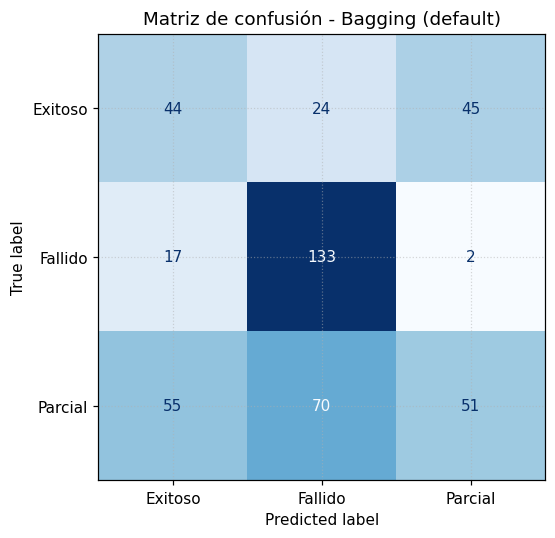

F1 por clase - Bagging (default)


,F1
Exitoso,0.384279
Fallido,0.701847
Parcial,0.372263


In [23]:
predbag1 = le.inverse_transform(bag1.predict(X_test_enc))
predbag2 = le.inverse_transform(bag2.predict(X_test_enc))

print("=== BAGGING base ===")
display(tabla_confusion(y_true_labels, predbag1)); evaluar_modelo(y_true_labels, predbag1, "Bagging (default)")


Real,Exitoso,Fallido,Parcial
Pred,,,
Fallido,29,141,84
Parcial,84,11,92


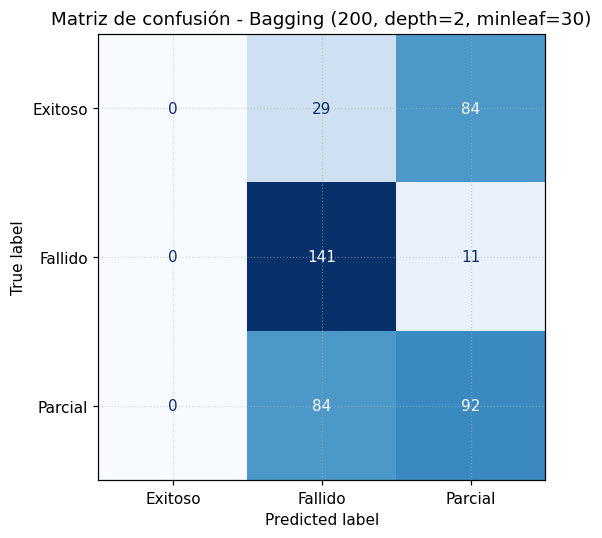

F1 por clase - Bagging (200, depth=2, minleaf=30)


,F1
Exitoso,0.000000
Fallido,0.694581
Parcial,0.506887


In [24]:
display(tabla_confusion(y_true_labels, predbag2)); evaluar_modelo(y_true_labels, predbag2, "Bagging (200, depth=2, minleaf=30)")

###Ejecución: Random Forest

In [25]:
# Random Forest (default y parametrizado)
rf1 = RandomForestClassifier(
    random_state=493825,
    n_jobs=-1
).fit(X_train_enc, y_train_enc)


In [26]:
rf2 = RandomForestClassifier(
    random_state=453824,
    n_estimators=1000,
    max_features=1,
    min_samples_leaf=2,
    n_jobs=-1
).fit(X_train_enc, y_train_enc)


=== RANDOM FOREST base ===


Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,44,17,55
Fallido,24,133,70
Parcial,45,2,51


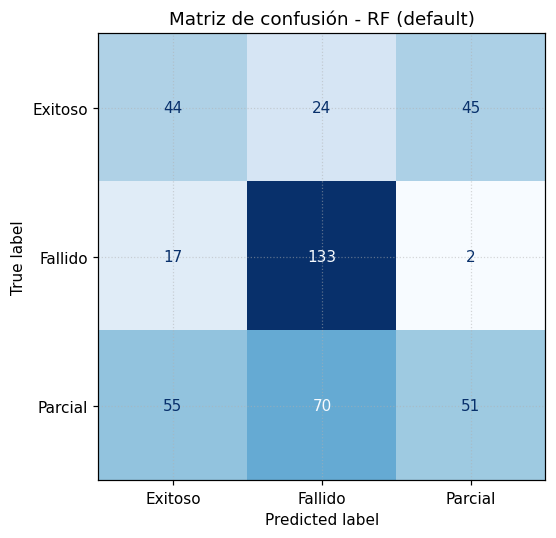

F1 por clase - RF (default)


,F1
Exitoso,0.384279
Fallido,0.701847
Parcial,0.372263


In [27]:
predrf1 = le.inverse_transform(rf1.predict(X_test_enc))
predrf2 = le.inverse_transform(rf2.predict(X_test_enc))

print("=== RANDOM FOREST base ===")
display(tabla_confusion(y_true_labels, predrf1)); evaluar_modelo(y_true_labels, predrf1, "RF (default)")


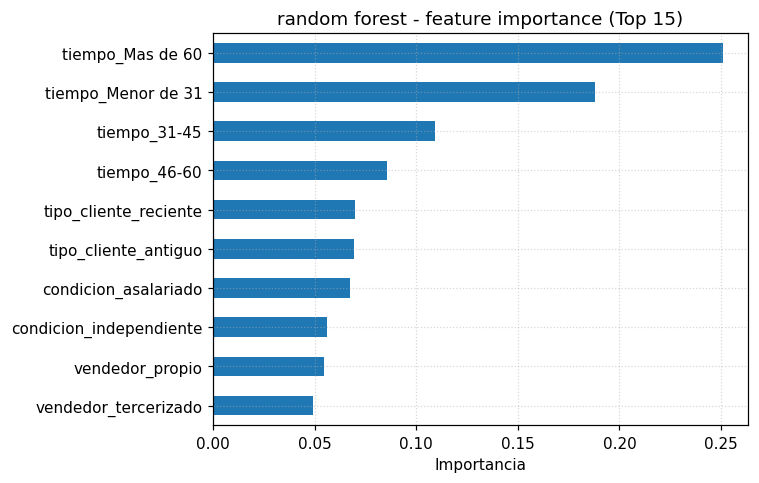

,0
tiempo_Mas de 60,0.250729
tiempo_Menor de 31,0.187902
tiempo_31-45,0.109336
tiempo_46-60,0.085570
tipo_cliente_reciente,0.069775
tipo_cliente_antiguo,0.069430
condicion_asalariado,0.067333
condicion_independiente,0.055961
vendedor_propio,0.054604
vendedor_tercerizado,0.049360


In [28]:
plot_importancias(rf1, feature_names, 15, "random forest - feature importance")

Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,39,9,41
Fallido,29,141,84
Parcial,45,2,51


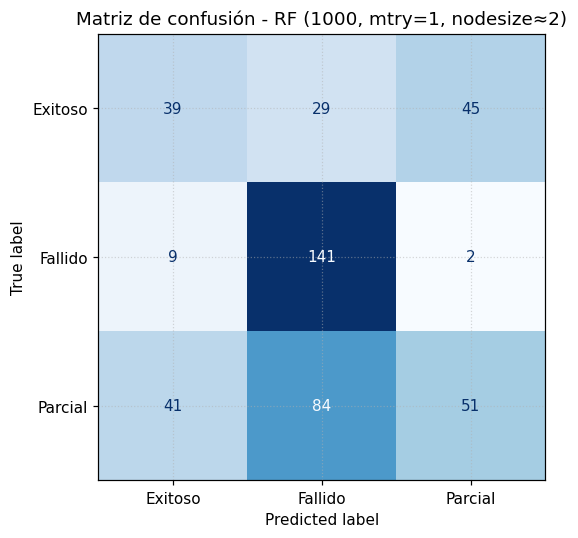

F1 por clase - RF (1000, mtry=1, nodesize≈2)


,F1
Exitoso,0.386139
Fallido,0.694581
Parcial,0.372263


In [29]:
display(tabla_confusion(y_true_labels, predrf2)); evaluar_modelo(y_true_labels, predrf2, "RF (1000, mtry=1, nodesize≈2)")

###Ejecución: adaboost

In [30]:
boost1 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42345),
    n_estimators=50,
    learning_rate=1.0,
    algorithm="SAMME",
    random_state=42345
).fit(X_train_enc, y_train_enc)



/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


In [31]:
boost2 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        random_state=32467,
        max_depth=2,
        min_samples_leaf=30
    ),
    n_estimators=200,
    learning_rate=1.0,
    algorithm="SAMME",
    random_state=439239
).fit(X_train_enc, y_train_enc)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,72,23,85
Fallido,11,112,55
Parcial,30,17,36


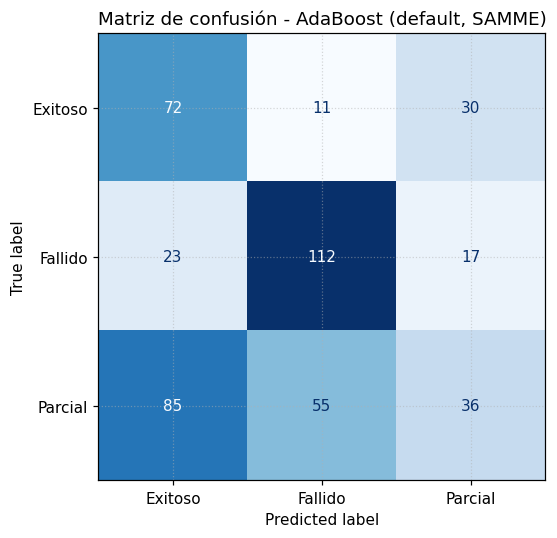

F1 por clase - AdaBoost (default, SAMME)


,F1
Exitoso,0.491468
Fallido,0.678788
Parcial,0.277992


In [32]:
pr5 = le.inverse_transform(boost1.predict(X_test_enc))
pr6 = le.inverse_transform(boost2.predict(X_test_enc))
display(tabla_confusion(y_true_labels, pr5)); evaluar_modelo(y_true_labels, pr5, "AdaBoost (default, SAMME)")

Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,52,3,42
Fallido,6,94,29
Parcial,55,55,105


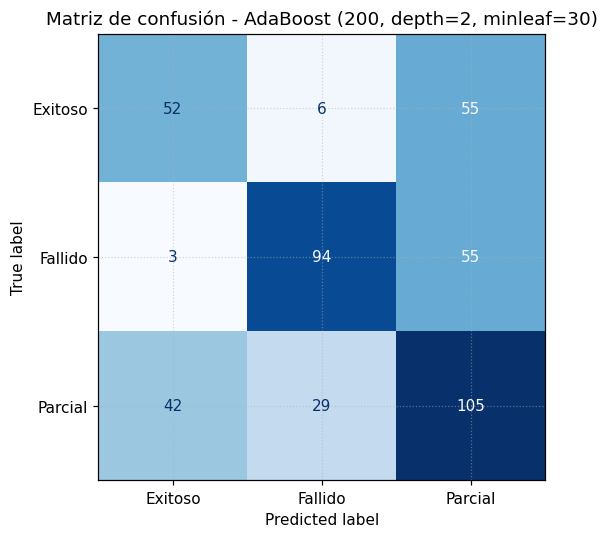

F1 por clase - AdaBoost (200, depth=2, minleaf=30)


,F1
Exitoso,0.495238
Fallido,0.669039
Parcial,0.537084


In [33]:
display(tabla_confusion(y_true_labels, pr6)); evaluar_modelo(y_true_labels, pr6, "AdaBoost (200, depth=2, minleaf=30)")

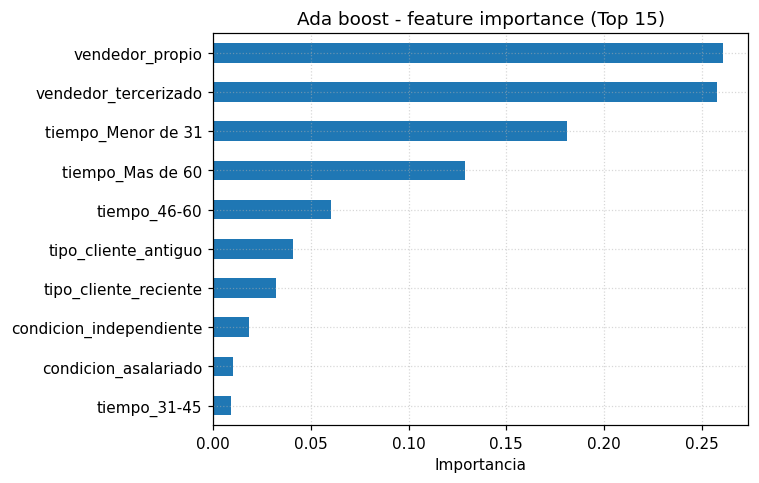

,0
vendedor_propio,0.260689
vendedor_tercerizado,0.257962
tiempo_Menor de 31,0.181252
tiempo_Mas de 60,0.129098
tiempo_46-60,0.060321
tipo_cliente_antiguo,0.040666
tipo_cliente_reciente,0.032242
condicion_independiente,0.018395
condicion_asalariado,0.010092
tiempo_31-45,0.009284


In [34]:
plot_importancias(boost2, feature_names, 15, "Ada boost - feature importance")

###Ejecución: extreme gradient boosting

In [35]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    n_estimators=400,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=230329,
    n_jobs=-1
).fit(X_train_enc, y_train_enc)


=== XGBOOST base ===


Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,31,6,28
Fallido,29,141,84
Parcial,53,5,64


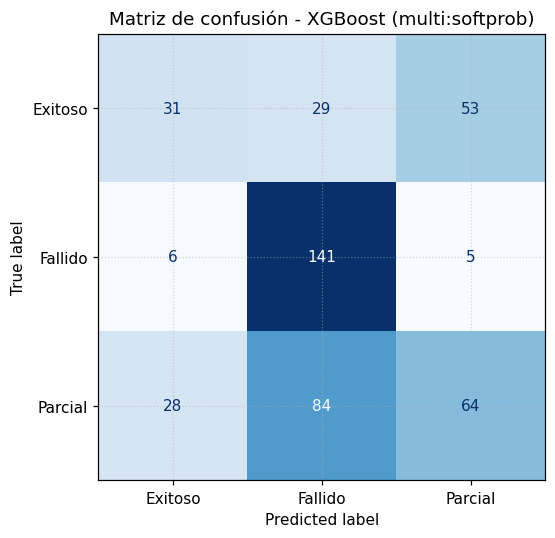

F1 por clase - XGBoost (multi:softprob)


,F1
Exitoso,0.348315
Fallido,0.694581
Parcial,0.429530


In [36]:
pred_xgb = le.inverse_transform(np.argmax(xgb.predict_proba(X_test_enc), axis=1))

print("=== XGBOOST base ===")
display(tabla_confusion(y_true_labels, pred_xgb)); evaluar_modelo(y_true_labels, pred_xgb, "XGBoost (multi:softprob)")


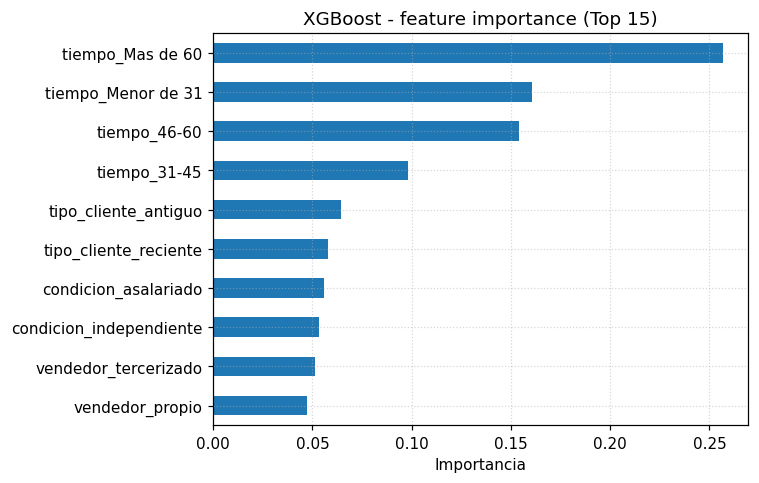

,0
tiempo_Mas de 60,0.256597
tiempo_Menor de 31,0.160786
tiempo_46-60,0.154206
tiempo_31-45,0.098101
tipo_cliente_antiguo,0.064534
tipo_cliente_reciente,0.057855
condicion_asalariado,0.055832
condicion_independiente,0.053303
vendedor_tercerizado,0.051475
vendedor_propio,0.047311


In [37]:
plot_importancias(xgb, feature_names, 15, "XGBoost - feature importance")

###sintonizando los hiperparámetros

In [38]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=23938)

# --- Random Forest
rf_grid = {
    "n_estimators": [300, 700, 1000],
    "max_features": ["sqrt", "log2", 1],   # 1 ≈ mtry=1 de randomForest en R
    "min_samples_leaf": [1, 2, 5]
}
rf_gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=493489, n_jobs=-1),
    param_grid=rf_grid,
    scoring="accuracy",
    cv=cv5,
    n_jobs=-1,
    refit=True
)
rf_gs.fit(X_train_enc, y_train_enc)
print("Mejores hiperparámetros RF:", rf_gs.best_params_)
print("Mejor score CV RF:", rf_gs.best_score_)


Mejores hiperparámetros RF: {'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
Mejor score CV RF: 0.5307993730407524


=== RF (GridSearch) ===


Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,31,6,28
Fallido,29,141,84
Parcial,53,5,64


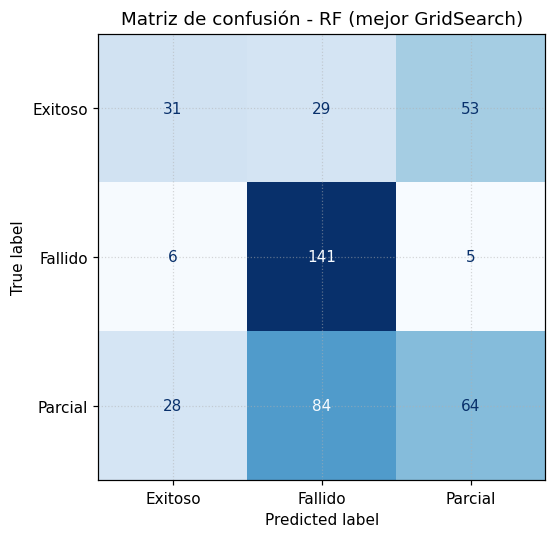

F1 por clase - RF (mejor GridSearch)


,F1
Exitoso,0.348315
Fallido,0.694581
Parcial,0.429530


In [39]:
rf_best = rf_gs.best_estimator_
pred_rf_best = le.inverse_transform(rf_best.predict(X_test_enc))
print("=== RF (GridSearch) ===")
display(tabla_confusion(y_true_labels, pred_rf_best)); evaluar_modelo(y_true_labels, pred_rf_best, "RF (mejor GridSearch)")


In [40]:
xgb_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 2.0],
}
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    tree_method="hist",
    random_state=3293843,
    n_jobs=-1
)
xgb_gs = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_grid,
    scoring="accuracy",
    cv=cv5,
    n_jobs=-1,
    refit=True
)
xgb_gs.fit(X_train_enc, y_train_enc)
print("Mejores hiperparámetros XGB:", xgb_gs.best_params_)
print("Mejor score CV XGB:", xgb_gs.best_score_)



Mejores hiperparámetros XGB: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_lambda': 1.0, 'subsample': 1.0}
Mejor score CV XGB: 0.5330459770114943


=== XGBOOST (GridSearch) ===


Real,Exitoso,Fallido,Parcial
Pred,,,
Exitoso,31,6,28
Fallido,24,121,72
Parcial,58,25,76


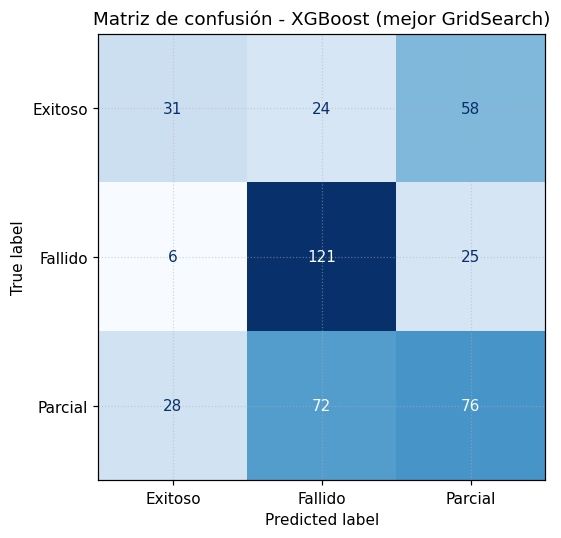

F1 por clase - XGBoost (mejor GridSearch)


,F1
Exitoso,0.348315
Fallido,0.655827
Parcial,0.453731


In [41]:
xgb_best = xgb_gs.best_estimator_
pred_xgb_best = le.inverse_transform(np.argmax(xgb_best.predict_proba(X_test_enc), axis=1))
print("=== XGBOOST (GridSearch) ===")
display(tabla_confusion(y_true_labels, pred_xgb_best)); evaluar_modelo(y_true_labels, pred_xgb_best, "XGBoost (mejor GridSearch)")


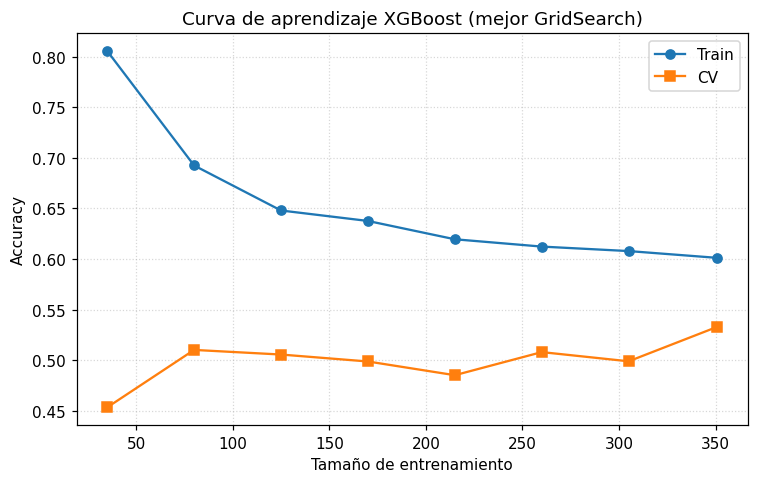

In [42]:
def graficar_curva_aprendizaje(model, X, y, cv, titulo):
    sizes, train_scores, valid_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.1, 1.0, 8),
        cv=cv, scoring="accuracy", n_jobs=-1, shuffle=True, random_state=49528
    )
    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)

    plt.figure(figsize=(7, 4.5))
    plt.plot(sizes, train_mean, marker="o", label="Train")
    plt.plot(sizes, valid_mean, marker="s", label="CV")
    plt.xlabel("Tamaño de entrenamiento")
    plt.ylabel("Accuracy")
    plt.title(titulo)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Curva de aprendizaje para XGBoost (mejor encontrado)
graficar_curva_aprendizaje(
    xgb_best, X_train_enc, y_train_enc, cv5,
    "Curva de aprendizaje XGBoost (mejor GridSearch)"
)



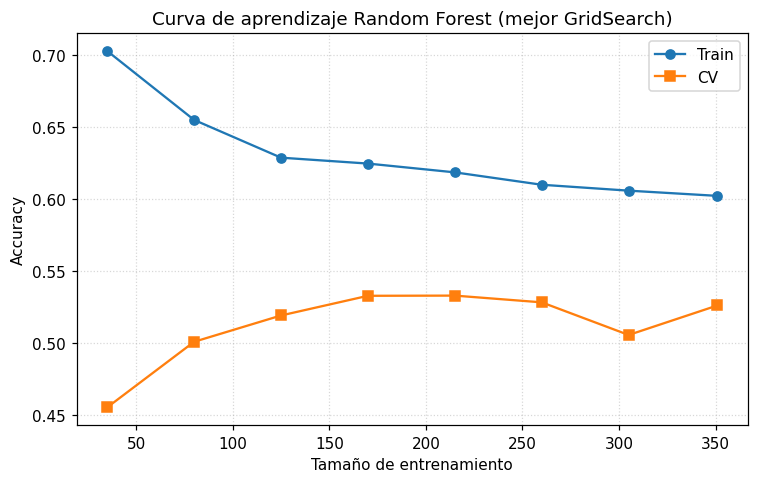

In [43]:
graficar_curva_aprendizaje(
    rf_best, X_train_enc, y_train_enc, cv5,
    "Curva de aprendizaje Random Forest (mejor GridSearch)"
)


In [44]:
modelos = {
    "Bagging (default)": bag1,
    "Bagging (200, depth=2, minleaf=30)": bag2,
    "RF (default)": rf1,
    "RF (param)": rf2,
    "RF (GridSearch)": rf_best,
    "AdaBoost (default)": boost1,
    "AdaBoost (200, depth=2, minleaf=30)": boost2,
    "XGBoost (base)": xgb,
    "XGBoost (GridSearch)": xgb_best
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=34204)
print("\n=== Accuracy CV 5-fold (media ± sd) ===")
for nombre, mdl in modelos.items():
    scores = cross_val_score(mdl, X_train_enc, y_train_enc, cv=cv, n_jobs=-1)
    print(f"{nombre:32s}: {scores.mean():.3f} ± {scores.std():.3f}")




=== Accuracy CV 5-fold (media ± sd) ===
Bagging (default)               : 0.483 ± 0.018
Bagging (200, depth=2, minleaf=30): 0.501 ± 0.042
RF (default)                    : 0.499 ± 0.035
RF (param)                      : 0.497 ± 0.009
RF (GridSearch)                 : 0.515 ± 0.022
AdaBoost (default)              : 0.490 ± 0.012
AdaBoost (200, depth=2, minleaf=30): 0.535 ± 0.040
XGBoost (base)                  : 0.499 ± 0.025
XGBoost (GridSearch)            : 0.531 ± 0.032
